In [4]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter

df = pd.read_csv('groceries.csv', header=None)
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

print(f"Number of transactions: {len(transactions)}")
print("First transaction:", transactions[0])
print("Middle transaction:", transactions[len(transactions) // 2])
print("Last transaction:", transactions[-1])

items = set()
for t in transactions:
    items.update(t)

print(f"Number of unique items: {len(items)}")

item_counts = Counter()
for t in transactions:
    item_counts.update(t)

print(item_counts.most_common(10))

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

print(basket.shape)

Number of transactions: 9835
First transaction: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
Middle transaction: ['domestic eggs']
Last transaction: ['chicken', 'tropical fruit', 'other vegetables', 'vinegar', 'shopping bags']
Number of unique items: 169
[('whole milk', 2513), ('other vegetables', 1903), ('rolls/buns', 1809), ('soda', 1715), ('yogurt', 1372), ('bottled water', 1087), ('root vegetables', 1072), ('tropical fruit', 1032), ('shopping bags', 969), ('sausage', 924)]
(9835, 169)


In [6]:
#Find at least 10 frequent itemsets containing two or more products.

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

multi_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2]
print(multi_itemsets.head(10))

     support                                     itemsets  length
88  0.019725          frozenset({beef, other vegetables})       2
89  0.013625                frozenset({beef, rolls/buns})       2
90  0.017387           frozenset({beef, root vegetables})       2
91  0.021251                frozenset({beef, whole milk})       2
92  0.011693                    frozenset({yogurt, beef})       2
93  0.010269       frozenset({berries, other vegetables})       2
94  0.011795             frozenset({berries, whole milk})       2
95  0.010574                 frozenset({yogurt, berries})       2
96  0.015760     frozenset({bottled beer, bottled water})       2
97  0.016167  frozenset({bottled beer, other vegetables})       2


In [7]:
print(multi_itemsets['length'].value_counts())

length
2    213
3     32
Name: count, dtype: int64


In [8]:
top10 = multi_itemsets.sort_values('support', ascending=False).head(10)
print(top10)

      support                                        itemsets  length
239  0.074835       frozenset({other vegetables, whole milk})       2
267  0.056634             frozenset({rolls/buns, whole milk})       2
300  0.056024                 frozenset({yogurt, whole milk})       2
274  0.048907        frozenset({root vegetables, whole milk})       2
229  0.047382  frozenset({root vegetables, other vegetables})       2
240  0.043416           frozenset({yogurt, other vegetables})       2
228  0.042603       frozenset({rolls/buns, other vegetables})       2
294  0.042298         frozenset({tropical fruit, whole milk})       2
290  0.040061                   frozenset({soda, whole milk})       2
264  0.038332                   frozenset({soda, rolls/buns})       2


In [9]:
top10_triples = multi_itemsets[multi_itemsets['length'] == 3].sort_values('support', ascending=False).head(10)
print(top10_triples)

      support                                           itemsets  length
316  0.023183  frozenset({other vegetables, root vegetables, ...       3
324  0.022267  frozenset({yogurt, other vegetables, whole milk})       3
313  0.017895  frozenset({other vegetables, rolls/buns, whole...       3
320  0.017082  frozenset({other vegetables, tropical fruit, w...       3
327  0.015557        frozenset({yogurt, rolls/buns, whole milk})       3
331  0.015150    frozenset({yogurt, tropical fruit, whole milk})       3
322  0.014642  frozenset({whipped/sour cream, other vegetable...       3
329  0.014540   frozenset({yogurt, root vegetables, whole milk})       3
319  0.013930    frozenset({other vegetables, soda, whole milk})       3
310  0.013523  frozenset({other vegetables, pip fruit, whole ...       3


In [10]:
#Question 3: Association Rules

#a. Generate at least 10 association rules.

from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                  antecedents                    consequents   support  \
0           frozenset({beef})  frozenset({other vegetables})  0.019725   
1           frozenset({beef})   frozenset({root vegetables})  0.017387   
2           frozenset({beef})        frozenset({whole milk})  0.021251   
3        frozenset({berries})  frozenset({other vegetables})  0.010269   
4        frozenset({berries})        frozenset({whole milk})  0.011795   
5        frozenset({berries})            frozenset({yogurt})  0.010574   
6  frozenset({bottled water})        frozenset({whole milk})  0.034367   
7    frozenset({brown bread})        frozenset({whole milk})  0.025216   
8         frozenset({butter})  frozenset({other vegetables})  0.020031   
9         frozenset({butter})        frozenset({whole milk})  0.027555   

   confidence      lift  
0    0.375969  1.943066  
1    0.331395  3.040367  
2    0.405039  1.585180  
3    0.308869  1.596280  
4    0.354740  1.388328  
5    0.318043  2.279848  
6  

In [11]:
print(len(rules))

125


In [12]:
highest_confidence = rules.sort_values('confidence', ascending=False).head(1)
highest_lift = rules.sort_values('lift', ascending=False).head(1)
highest_support = rules.sort_values('support', ascending=False).head(1)

print(highest_confidence[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print(highest_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
print(highest_support[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                   antecedents                    consequents  \
73  frozenset({citrus fruit, root vegetables})  frozenset({other vegetables})   

     support  confidence      lift  
73  0.010371    0.586207  3.029608  
                                    antecedents                   consequents  \
74  frozenset({citrus fruit, other vegetables})  frozenset({root vegetables})   

     support  confidence      lift  
74  0.010371    0.359155  3.295045  
                      antecedents              consequents   support  \
53  frozenset({other vegetables})  frozenset({whole milk})  0.074835   

    confidence      lift  
53    0.386758  1.513634  


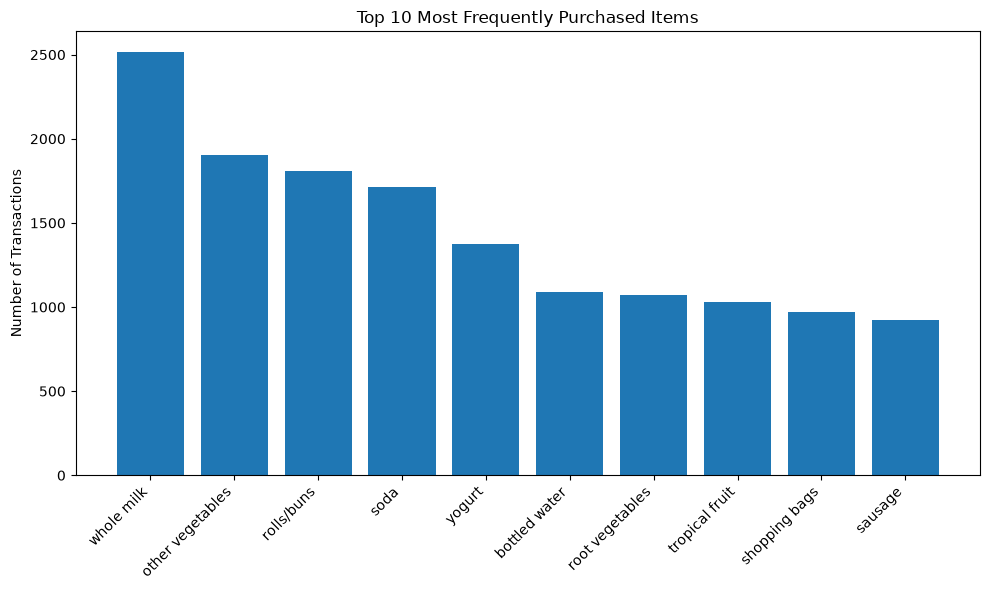

In [13]:
import matplotlib.pyplot as plt

top_items = dict(item_counts.most_common(10))

plt.figure(figsize=(10, 6))
plt.bar(top_items.keys(), top_items.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Transactions')
plt.title('Top 10 Most Frequently Purchased Items')
plt.tight_layout()
plt.savefig('top10_items.png')
plt.show()